In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!pip install torch==2.11.0 torchvision==0.26.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.3 MB/s eta 0:00:00


In [2]:
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix,
                             recall_score, balanced_accuracy_score, accuracy_score,
                             precision_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

SEEDS = [42, 123, 456, 789, 2024]
CLASSES = ['BCC','MEL','SCC','ACK','NEV','SEK']

# Estilo de publicación
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
print('Setup listo')

Dispositivo: cuda
Setup listo


## 1. Cargar datos (embeddings + metadata + labels)

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')
FIG_PATH     = os.path.join(RESULTS_PATH, 'figuras_paper')
os.makedirs(FIG_PATH, exist_ok=True)

# Reconstruir dataset completo en orden train+val+test
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

clip_all = np.concatenate([np.load(os.path.join(RESULTS_PATH,'clip_X_train.npy')),
                           np.load(os.path.join(RESULTS_PATH,'clip_X_val.npy')),
                           np.load(os.path.join(RESULTS_PATH,'clip_X_test.npy'))], axis=0)
dino_all = np.concatenate([np.load(os.path.join(RESULTS_PATH,'dino_X_train.npy')),
                           np.load(os.path.join(RESULTS_PATH,'dino_X_val.npy')),
                           np.load(os.path.join(RESULTS_PATH,'dino_X_test.npy'))], axis=0)

CLS_IDX = {c:i for i,c in enumerate(CLASSES)}
y_bin   = df_all['label'].values.astype(int)
y_multi = df_all['diagnostic'].map(CLS_IDX).values

# Metadata one-hot
META_COLS = ['smoke','drink','pesticide','gender','skin_cancer_history','cancer_history',
             'has_piped_water','has_sewage_system','age','fitspatrick','diameter_1','diameter_2',
             'region','background_father','background_mother','itch','grew','hurt','changed','bleed','elevation']
NUM_COLS = ['age','fitspatrick','diameter_1','diameter_2']
meta_raw = df_all[META_COLS].copy()
for col in meta_raw.select_dtypes(include='bool').columns:
    meta_raw[col] = meta_raw[col].astype(int)
string_cats = [c for c in META_COLS if c not in NUM_COLS and meta_raw[c].dtype==object]
meta_all = pd.get_dummies(meta_raw, columns=string_cats).values.astype(np.float32)
meta_dim = meta_all.shape[1]

print(f'CLIP: {clip_all.shape} | DINOv2: {dino_all.shape} | Meta: {meta_all.shape}')
print(f'Binario: {np.bincount(y_bin)} | Multiclase: {np.bincount(y_multi)}')

CLIP: (2298, 768) | DINOv2: (2298, 1024) | Meta: (2298, 77)
Binario: [1209 1089] | Multiclase: [845  52 192 730 244 235]


## 2. Modelos y utilidades (idénticos al notebook 12)

In [4]:
def set_seed(s):
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed(s)

def scale_meta(mtr, mva, mte):
    sc = MinMaxScaler(); idx = list(range(4))
    a,b,c = mtr.copy(), mva.copy(), mte.copy()
    a[:,idx] = sc.fit_transform(a[:,idx]); b[:,idx] = sc.transform(b[:,idx]); c[:,idx] = sc.transform(c[:,idx])
    return a,b,c

def split_idx(y, seed):
    set_seed(seed)
    s1 = StratifiedShuffleSplit(1, test_size=0.1, random_state=seed)
    tv, te = next(s1.split(np.zeros(len(y)), y))
    s2 = StratifiedShuffleSplit(1, test_size=0.1/0.9, random_state=seed)
    tr_r, va_r = next(s2.split(np.zeros(len(tv)), y[tv]))
    return tv[tr_r], tv[va_r], te

class LinearHead(nn.Module):
    def __init__(self, d, n=1, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,512), nn.ReLU(), nn.Dropout(drop),
                                 nn.Linear(512,256), nn.ReLU(), nn.Dropout(drop),
                                 nn.Linear(256,n))
    def forward(self,x): return self.net(x)

class FocalMulti(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self, logits, targets):
        logp = F.log_softmax(logits,1)
        ce = F.nll_loss(logp, targets, weight=self.alpha, reduction='none')
        return ((1-torch.exp(-ce))**self.gamma * ce).mean()

def train_head(Xtr,ytr,Xv,yv,Xte,yte,is_bin,n_cls,crit,epochs=50,pat=12,lr=1e-3):
    yt = torch.float32 if is_bin else torch.long
    tl = DataLoader(TensorDataset(torch.tensor(Xtr,dtype=torch.float32),torch.tensor(ytr,dtype=yt)),batch_size=64,shuffle=True)
    vl = DataLoader(TensorDataset(torch.tensor(Xv,dtype=torch.float32),torch.tensor(yv,dtype=yt)),batch_size=64)
    tel= DataLoader(TensorDataset(torch.tensor(Xte,dtype=torch.float32),torch.tensor(yte,dtype=yt)),batch_size=64)
    mdl = LinearHead(Xtr.shape[1], n=n_cls).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best, best_state, p = 0, None, 0
    for ep in range(epochs):
        mdl.train()
        for xb,yb in tl:
            xb,yb = xb.to(device),yb.to(device); opt.zero_grad()
            out = mdl(xb).squeeze(1) if is_bin else mdl(xb)
            loss = crit(out,yb); loss.backward(); opt.step()
        mdl.eval(); vp,vt,vl_=[],[],0
        with torch.no_grad():
            for xb,yb in vl:
                xb,yb=xb.to(device),yb.to(device)
                out = mdl(xb).squeeze(1) if is_bin else mdl(xb)
                vl_ += crit(out,yb).item()
                if is_bin: vp.extend(torch.sigmoid(out).cpu().numpy())
                else: vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(yb.cpu().numpy())
        sch.step(vl_)
        score = roc_auc_score(vt,vp) if is_bin else balanced_accuracy_score(vt,vp)
        if score>best: best,best_state,p = score,{k:v.cpu().clone() for k,v in mdl.state_dict().items()},0
        else:
            p+=1
            if p>=pat: break
    mdl.load_state_dict(best_state); mdl.eval()
    tp,tpr,tt=[],[],[]
    with torch.no_grad():
        for xb,yb in tel:
            out = mdl(xb.to(device)).squeeze(1) if is_bin else mdl(xb.to(device))
            if is_bin:
                tp.extend(torch.sigmoid(out).cpu().numpy())
                tpr.extend((torch.sigmoid(out)>=0.5).long().cpu().numpy())
            else:
                tp.extend(torch.softmax(out,1).cpu().numpy())
                tpr.extend(out.argmax(1).cpu().numpy())
            tt.extend(yb.numpy())
    return np.array(tp), np.array(tpr), np.array(tt)

def feats_bin(name, ti, vi, tei):
    """Devuelve features concatenados para el modelo dado."""
    if name == 'CLIP + metadata':
        m = scale_meta(meta_all[ti],meta_all[vi],meta_all[tei])
        return (np.concatenate([clip_all[ti],m[0]],1),np.concatenate([clip_all[vi],m[1]],1),np.concatenate([clip_all[tei],m[2]],1))
    if name == 'DINOv2 + metadata':
        m = scale_meta(meta_all[ti],meta_all[vi],meta_all[tei])
        return (np.concatenate([dino_all[ti],m[0]],1),np.concatenate([dino_all[vi],m[1]],1),np.concatenate([dino_all[tei],m[2]],1))
    if name == 'CLIP+DINOv2+metadata':
        m = scale_meta(meta_all[ti],meta_all[vi],meta_all[tei])
        return (np.concatenate([clip_all[ti],dino_all[ti],m[0]],1),
                np.concatenate([clip_all[vi],dino_all[vi],m[1]],1),
                np.concatenate([clip_all[tei],dino_all[tei],m[2]],1))
    if name == 'CLIP solo':
        return clip_all[ti],clip_all[vi],clip_all[tei]
    if name == 'DINOv2 solo':
        return dino_all[ti],dino_all[vi],dino_all[tei]


## FIGURA 1 — Curva ROC binaria con banda de confianza
La figura más característica de clasificación médica. Muestra la curva ROC promedio
sobre las 5 semillas, con banda sombreada = ± 1 desviación estándar.

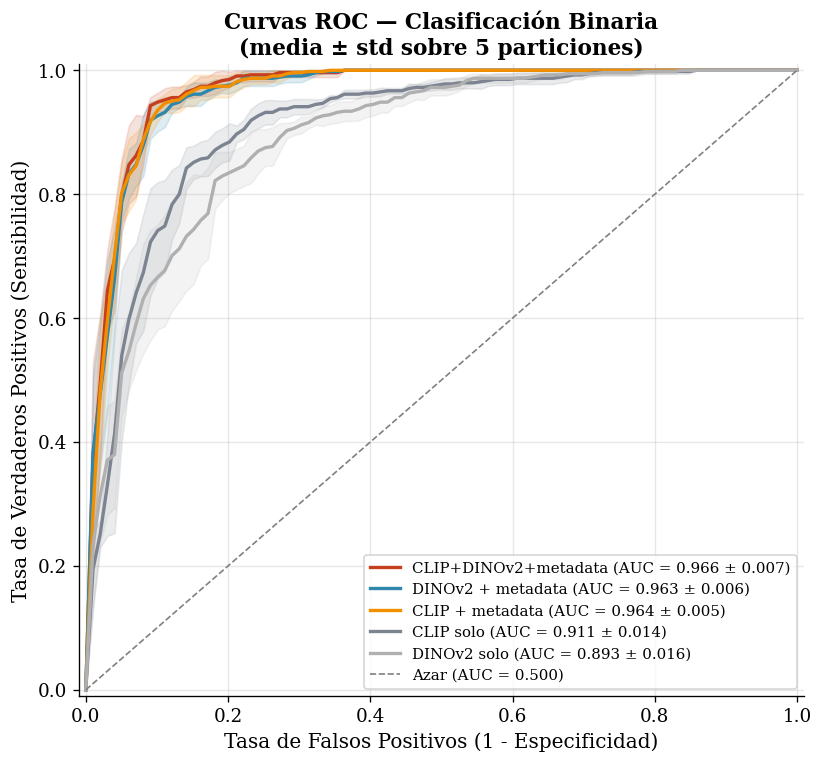

 Figura ROC guardada (PNG + PDF)


In [5]:
# Modelos a incluir en la curva ROC (los más relevantes para no saturar)
roc_models = ['CLIP+DINOv2+metadata', 'DINOv2 + metadata', 'CLIP + metadata', 'CLIP solo', 'DINOv2 solo']
roc_colors = ['#C73E1D', '#2E86AB', '#F18F01', '#7D8491', '#B0B0B0']

# Grid común de FPR para interpolar
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(7, 6.5))

for name, color in zip(roc_models, roc_colors):
    tprs = []
    aucs = []
    for seed in SEEDS:
        ti, vi, tei = split_idx(y_bin, seed)
        Xtr, Xv, Xte = feats_bin(name, ti, vi, tei)
        probs, _, true = train_head(Xtr, y_bin[ti], Xv, y_bin[vi], Xte, y_bin[tei],
                                     is_bin=True, n_cls=1, crit=nn.BCEWithLogitsLoss())
        fpr, tpr, _ = roc_curve(true, probs)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
    std_tpr  = np.std(tprs, axis=0)
    mean_auc = np.mean(aucs); std_auc = np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
            label=f'{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
    ax.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1),
                    color=color, alpha=0.15)

ax.plot([0,1],[0,1], linestyle='--', color='gray', lw=1, label='Azar (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC — Clasificación Binaria\n(media ± std sobre 5 particiones)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, frameon=True)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_roc_binario.png'))
plt.savefig(os.path.join(FIG_PATH, 'fig_roc_binario.pdf'))  # PDF vectorial para LaTeX
plt.show()
print(' Figura ROC guardada (PNG + PDF)')

## FIGURA 2 — Barras comparativas con error bars (binario)
Versión visual de la tabla principal. Requiere el CSV del notebook 12.

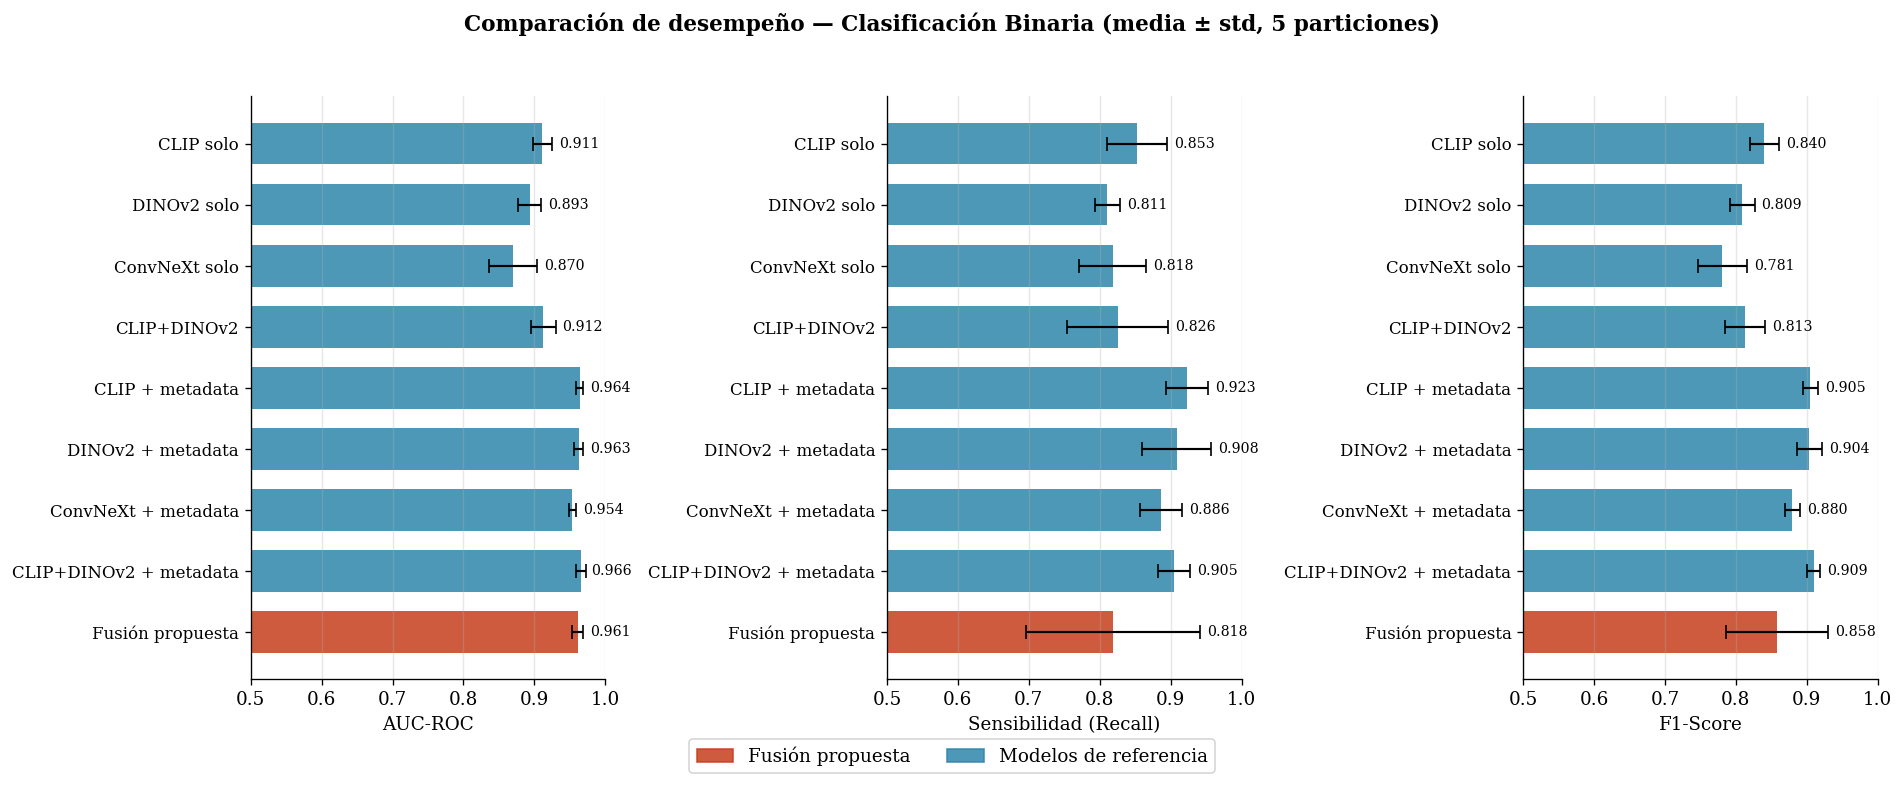

 Figura de barras guardada


In [6]:
# Cargar resultados multi-semilla del notebook 12
MULTI_PATH = os.path.join(RESULTS_PATH, 'multisemilla')
df_bin = pd.read_csv(os.path.join(MULTI_PATH, 'multisemilla_binario_completo.csv'))

orden = ['CLIP solo','DINOv2 solo','ConvNeXt solo','CLIP+DINOv2',
         'CLIP + metadata','DINOv2 + metadata','ConvNeXt + metadata',
         'CLIP+DINOv2 + metadata','Fusión propuesta']
df_bin['ord'] = df_bin['modelo'].map({m:i for i,m in enumerate(orden)})
df_bin = df_bin.sort_values('ord').reset_index(drop=True)

metricas = ['auc','recall','f1']
labels   = ['AUC-ROC','Sensibilidad (Recall)','F1-Score']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, met, lab in zip(axes, metricas, labels):
    medias = df_bin[met].values; stds = df_bin[met+'_std'].values
    colors = ['#C73E1D' if 'propuesta' in m.lower() else '#2E86AB' for m in df_bin['modelo']]
    ax.barh(range(len(df_bin)), medias, xerr=stds, color=colors, alpha=0.85,
            capsize=4, height=0.68, error_kw={'linewidth':1.3})
    ax.set_yticks(range(len(df_bin))); ax.set_yticklabels(df_bin['modelo'], fontsize=10)
    ax.set_xlabel(lab, fontsize=11); ax.set_xlim(0.5,1.0); ax.invert_yaxis()
    for i,(m,s) in enumerate(zip(medias,stds)):
        ax.text(min(m+s+0.01,0.98), i, f'{m:.3f}', va='center', fontsize=8.5)
    ax.grid(axis='x', alpha=0.3)

p1 = mpatches.Patch(color='#C73E1D', alpha=0.85, label='Fusión propuesta')
p2 = mpatches.Patch(color='#2E86AB', alpha=0.85, label='Modelos de referencia')
fig.legend(handles=[p1,p2], loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04), fontsize=11)
plt.suptitle('Comparación de desempeño — Clasificación Binaria (media ± std, 5 particiones)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_barras_binario.png'))
plt.savefig(os.path.join(FIG_PATH, 'fig_barras_binario.pdf'))
plt.show()
print(' Figura de barras guardada')

## FIGURA 3 — Matriz de confusión multiclase
Del mejor modelo (CLIP+DINOv2+metadata). Normalizada por fila = sensibilidad por clase.

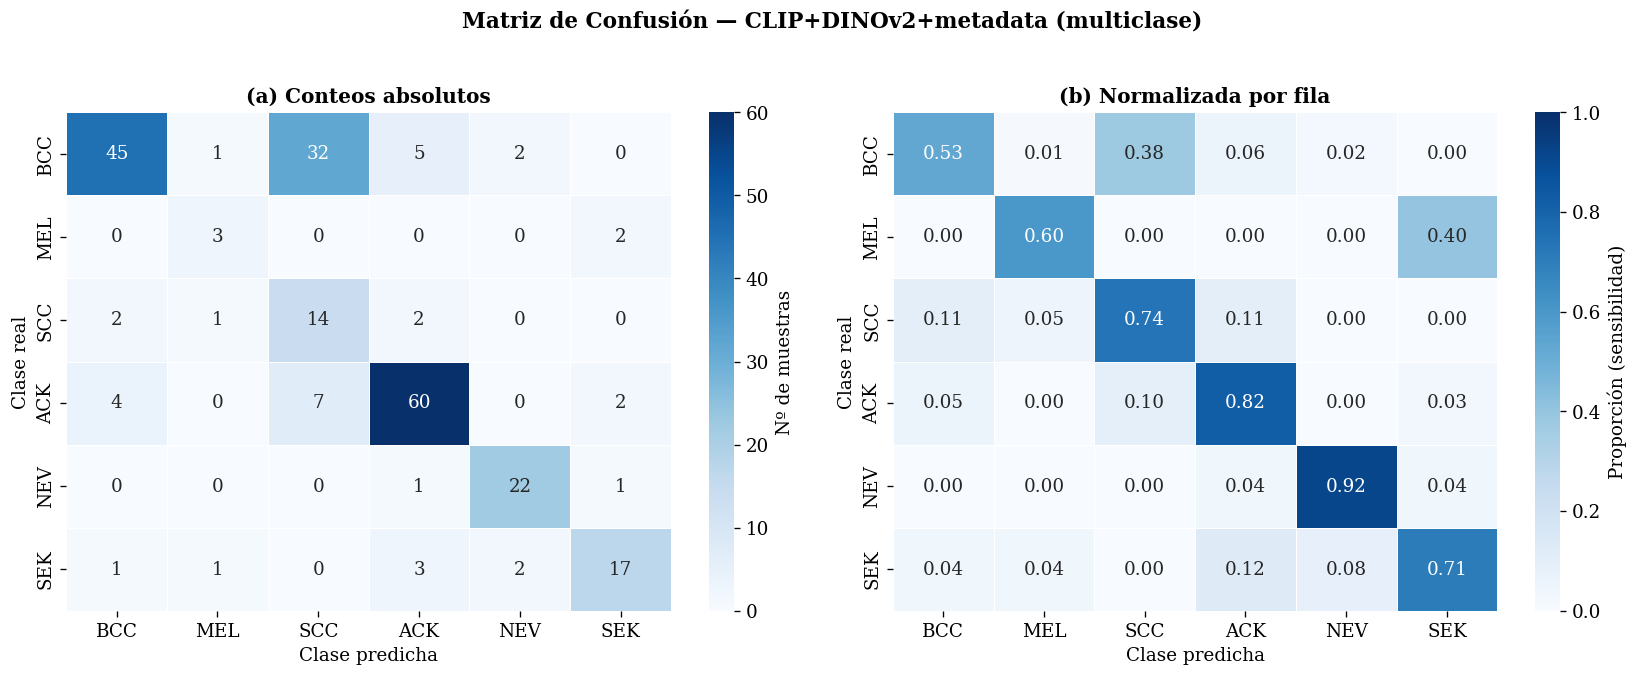

 Matriz de confusión guardada


In [7]:
# Entrenar el mejor modelo multiclase en la semilla 42 para la matriz
ti, vi, tei = split_idx(y_multi, 42)
m_s = scale_meta(meta_all[ti], meta_all[vi], meta_all[tei])
Xtr = np.concatenate([clip_all[ti],dino_all[ti],m_s[0]],1)
Xv  = np.concatenate([clip_all[vi],dino_all[vi],m_s[1]],1)
Xte = np.concatenate([clip_all[tei],dino_all[tei],m_s[2]],1)

cnts = np.bincount(y_multi[ti], minlength=6)
wts  = torch.tensor(len(y_multi[ti])/(6*cnts), dtype=torch.float32).to(device)
crit = FocalMulti(alpha=wts, gamma=2.0)

_, preds, true = train_head(Xtr, y_multi[ti], Xv, y_multi[vi], Xte, y_multi[tei],
                            is_bin=False, n_cls=6, crit=crit)

cm = confusion_matrix(true, preds, labels=range(6))
cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], linewidths=0.5, linecolor='white', cbar_kws={'label':'Nº de muestras'})
axes[0].set_title('(a) Conteos absolutos', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Clase real', fontsize=11); axes[0].set_xlabel('Clase predicha', fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            cbar_kws={'label':'Proporción (sensibilidad)'})
axes[1].set_title('(b) Normalizada por fila', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Clase real', fontsize=11); axes[1].set_xlabel('Clase predicha', fontsize=11)

plt.suptitle('Matriz de Confusión — CLIP+DINOv2+metadata (multiclase)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_confusion_multiclase.png'))
plt.savefig(os.path.join(FIG_PATH, 'fig_confusion_multiclase.pdf'))
plt.show()
print(' Matriz de confusión guardada')

## FIGURA 4 — Heatmap de sensibilidad por clase
Muestra la sensibilidad (recall) de los 9 modelos para cada una de las 6 clases,
promediada sobre las 5 semillas. Las clases malignas (BCC, MEL, SCC) se resaltan.

Cargado desde CSV del notebook 12


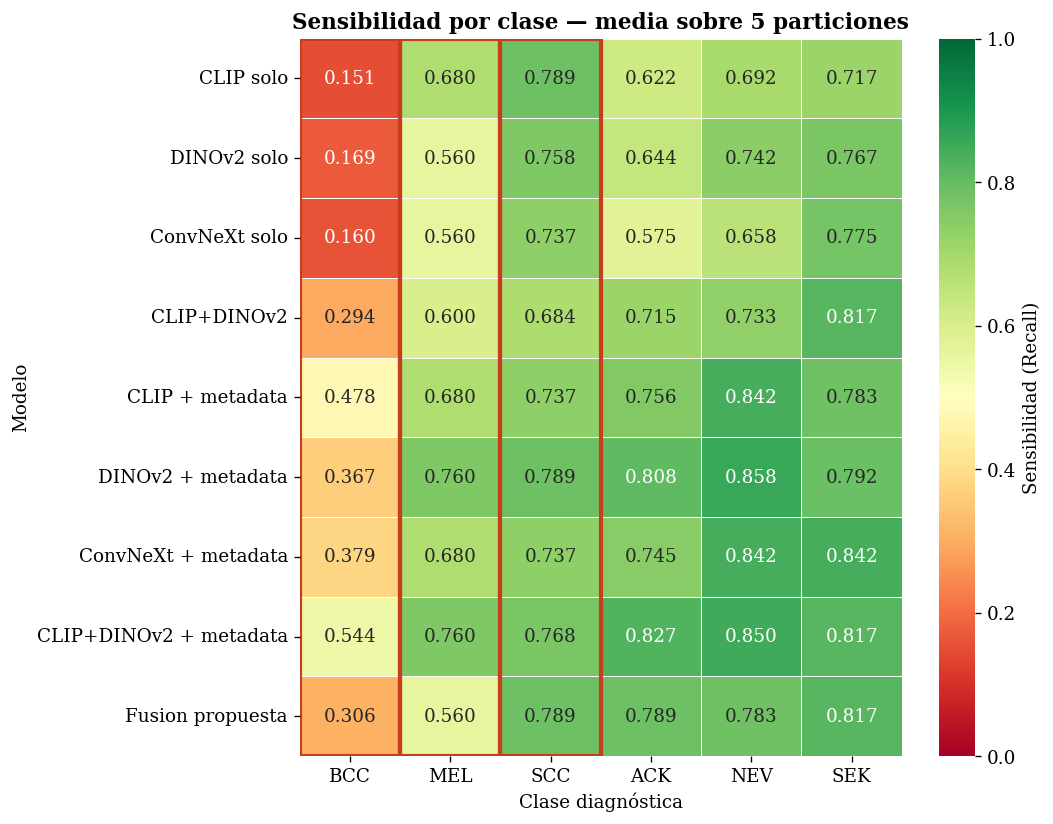

 Heatmap de sensibilidad guardado


In [8]:
# Si el notebook 12 ya guardó el CSV de sensibilidad, lo cargamos; si no, avisar
sens_csv = os.path.join(MULTI_PATH, 'sensibilidad_por_clase_multisemilla.csv')

if os.path.exists(sens_csv):
    hm = pd.read_csv(sens_csv, index_col=0)
    print('Cargado desde CSV del notebook 12')
else:
    print('CSV no encontrado — genera primero la Figura 6 del notebook 12,')
    print('o descomenta el bloque de cálculo completo abajo.')
    hm = None

if hm is not None:
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(hm, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
                linewidths=0.5, linecolor='white', cbar_kws={'label':'Sensibilidad (Recall)'})
    ax.set_title('Sensibilidad por clase — media sobre 5 particiones', fontsize=13, fontweight='bold')
    ax.set_xlabel('Clase diagnóstica', fontsize=11); ax.set_ylabel('Modelo', fontsize=11)
    for j,c in enumerate(hm.columns):
        if c in ['BCC','MEL','SCC']:
            ax.add_patch(plt.Rectangle((j,0),1,len(hm), fill=False, edgecolor='#C73E1D', lw=2.5))
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, 'fig_sensibilidad_clase.png'))
    plt.savefig(os.path.join(FIG_PATH, 'fig_sensibilidad_clase.pdf'))
    plt.show()
    print(' Heatmap de sensibilidad guardado')

## Resumen de figuras generadas

In [9]:
print('=== FIGURAS PARA EL ARTÍCULO ===\n')
figs = [
    ('fig_roc_binario',        'Curva ROC binaria con banda de confianza'),
    ('fig_barras_binario',     'Barras comparativas (AUC, Recall, F1)'),
    ('fig_confusion_multiclase','Matriz de confusión multiclase'),
    ('fig_sensibilidad_clase', 'Heatmap sensibilidad por clase'),
]
for base, desc in figs:
    png = os.path.join(FIG_PATH, base+'.png')
    pdf = os.path.join(FIG_PATH, base+'.pdf')
    ok = 'ok' if os.path.exists(png) else 'no'
    print(f'  {ok} {base}.png / .pdf — {desc}')
print(f'\nRuta: {FIG_PATH}')
print('\nEn el LaTeX usa las versiones .pdf (vectoriales, se ven nítidas al imprimir)')

=== FIGURAS PARA EL ARTÍCULO ===

  ok fig_roc_binario.png / .pdf — Curva ROC binaria con banda de confianza
  ok fig_barras_binario.png / .pdf — Barras comparativas (AUC, Recall, F1)
  ok fig_confusion_multiclase.png / .pdf — Matriz de confusión multiclase
  ok fig_sensibilidad_clase.png / .pdf — Heatmap sensibilidad por clase

Ruta: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/figuras_paper

En el LaTeX usa las versiones .pdf (vectoriales, se ven nítidas al imprimir)
